##**Knapsack Problem**

In [ ]:
from PIL import Image
import requests
from io import BytesIO

In [ ]:
print('Multi-Airport System. Source: Visual representation created with Gemini AI).')
img = Image.open(BytesIO(requests.get('https://media.licdn.com/dms/image/v2/D4D12AQEsl5Fx0th7iw/article-cover_image-shrink_720_1280/B4DZywpvuMJoAI-/0/1772490267852?e=1775088000&v=beta&t=4YxDIOu3oW5uKQ3ADxx5Og8_3ufAEbq4fQkQSlztsp0').content))
img

####**Brief Problem Statement**
Given a set of items, each of them with a weight and a value, select a subset that maximizes total value without exceeding the knapsack's weight capacity. Each item can be taken at most once (binary choice).

###**The Knapsack Problem: Here Are the Items, Values, and Dependencies**
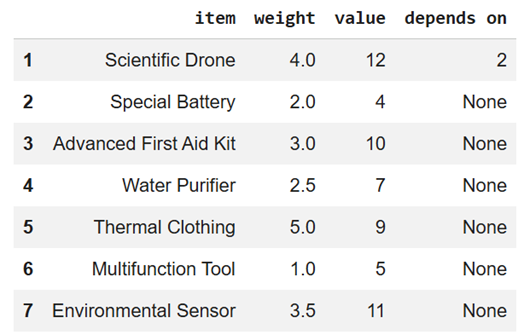

###**Descriptions and Bonus Values – This is the Twist**
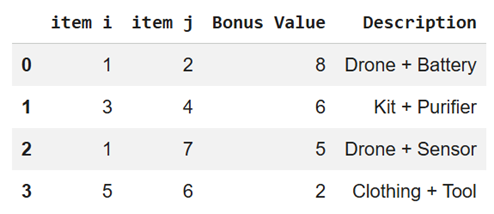

####**Objective Function**
Maximize the total utility, which is the sum of the values of the chosen items plus the bonuses from active synergies.
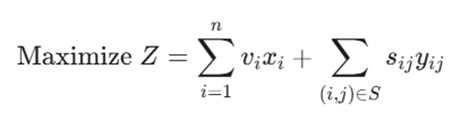

####**Capacity Constraint**
Cumulative weight of all selected items must not exceed the backpack maximum allowed capacity.

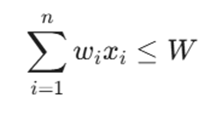

####**Logical Dependencies**
If item i depends on item d, then i cannot be selected unless d is also selected.

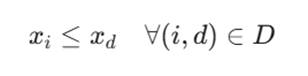

####**•	Synergy Linearization**
To ensure yij only takes the value 1 when both xi and xj are 1.

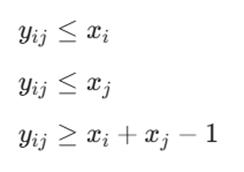

## **Main Solution**

In [37]:
# Data translation from the problema statement.
items = {
    1: {'item': "Scientific Drone", 'weight': 4.0, 'value': 12, 'depends_on': 2},
    2: {'item': "Special Battery", 'weight': 2.0, 'value': 4, 'depends_on': None},
    3: {'item': "Advanced First Aid Kit", 'weight': 3.0, 'value': 10, 'depends_on': None},
    4: {'item': "Water Purifier", 'weight': 2.5, 'value': 7, 'depends_on': None},
    5: {'item': "Thermal Clothing", 'weight': 5.0, 'value': 9, 'depends_on': None},
    6: {'item': "Multifunction Tool", 'weight': 1.0, 'value': 5, 'depends_on': None},
    7: {'item': "Environmental Sensor", 'weight': 3.5, 'value': 11, 'depends_on': None},
}
# Defining synergy pairs and their bonus value.
synergies = [(1, 2, 8), (3, 4, 6), (1, 7, 5), (5, 6, 2)]

# Defining the global constraint
max_capacity = 10.0


In [38]:
# Importing PuPL library
import pulp

# Create the model
model = pulp.LpProblem("Explorers_Knapsack", pulp.LpMaximize)

# Defined decision Variables: x for items, y for synergies (Binary)
x = pulp.LpVariable.dicts("item", items.keys(), cat=pulp.LpBinary)
y = pulp.LpVariable.dicts("syn", [(s[0], s[1]) for s in synergies], cat=pulp.LpBinary)

# Objective Function: Individual Values + Synergy Bonuses
model += pulp.lpSum([items[i]['value'] * x[i] for i in items]) + \
         pulp.lpSum([s[2] * y[(s[0], s[1])] for s in synergies])

# Constraints
model += pulp.lpSum([items[i]['weight'] * x[i] for i in items]) <= max_capacity

# Dependencies (e.g., Drone requires Battery)
for i, data in items.items():
    if data['depends_on']:
        model += x[i] <= x[data['depends_on']]

# Synergy Logic (Linearization)
for s in synergies:
    i, j, bonus = s
    model += y[(i, j)] <= x[i]
    model += y[(i, j)] <= x[j]
    model += y[(i, j)] >= x[i] + x[j] - 1

In [39]:
# Solve
model.solve(pulp.PULP_CBC_CMD(msg=0))

1

In [40]:
# Simple Results Display
if pulp.LpStatus[model.status] == 'Optimal':
    print("Optimal Selection for the Backpack:")
    print("----------------------------------")

    for i in items:
        # If the decision variable x[i] is 1, it means the item is selected
        if x[i].varValue == 1:
            item_name = items[i]['item']
            print(f"-> Selected: {item_name}")

    # Calculate the final results for the manager
    total_value = pulp.value(model.objective)
    total_weight = sum(items[i]['weight'] * pulp.value(x[i]) for i in items)
    print("----------------------------------")
    print(f"Total Value Generated: {total_value}")
    print(f"Total Weight: {total_weight}")
else:
    print("A feasible solution could not be found.")

Optimal Selection for the Backpack:
----------------------------------
-> Selected: Scientific Drone
-> Selected: Special Battery
-> Selected: Environmental Sensor
----------------------------------
Total Value Generated: 40.0
Total Weight: 9.5


## **Top 10 Possible Solutions**

In [44]:
# 3. Simulating all possible combinations to find the "Three Worlds"
all_combinations = []
item_ids = list(items.keys())

for r in range(len(item_ids) + 1):
    for combo in itertools.combinations(item_ids, r):
        current_weight = sum(items[i]['weight'] for i in combo)

        # Check logical dependencies (Source [47])
        logic_violated = False
        for i in combo:
            dep = items[i]['depends_on']
            if dep and dep not in combo:
                logic_violated = True
                break

        # Calculate base value + synergies (Source [42])
        base_val = sum(items[i]['value'] for i in combo)
        syn_val = sum(s[2] for s in synergies if s[0] in combo and s[1] in combo)
        total_val = base_val + syn_val

        # Determine status
        if current_weight > max_capacity:
            status = 'Overweight'
        elif logic_violated:
            status = 'Logic Error'
        else:
            status = 'Feasible'

        all_combinations.append({
            'combo': [items[i]['item'] for i in combo],
            'weight': current_weight,
            'value': total_val,
            'status': status
        })

df_all = pd.DataFrame(all_combinations)

df_all[df_all["status"] == "Feasible"].sort_values(by = "value", ascending = False).head(10)

,combo,weight,value,status
33,"[Scientific Drone, Special Battery, Environmen...",9.5,40,Feasible
96,"[Advanced First Aid Kit, Water Purifier, Multi...",10.0,39,Feasible
66,"[Scientific Drone, Special Battery, Advanced F...",10.0,39,Feasible
69,"[Scientific Drone, Special Battery, Water Puri...",9.5,36,Feasible
56,"[Advanced First Aid Kit, Water Purifier, Envir...",9.0,34,Feasible
29,"[Scientific Drone, Special Battery, Advanced F...",9.0,34,Feasible
85,"[Special Battery, Advanced First Aid Kit, Wate...",8.5,32,Feasible
30,"[Scientific Drone, Special Battery, Water Puri...",8.5,31,Feasible
89,"[Special Battery, Advanced First Aid Kit, Mult...",9.5,30,Feasible
32,"[Scientific Drone, Special Battery, Multifunct...",7.0,29,Feasible


##**Scatter Plot of All Solutions (Feasibles, Infeasibles, and LOgis Error)**

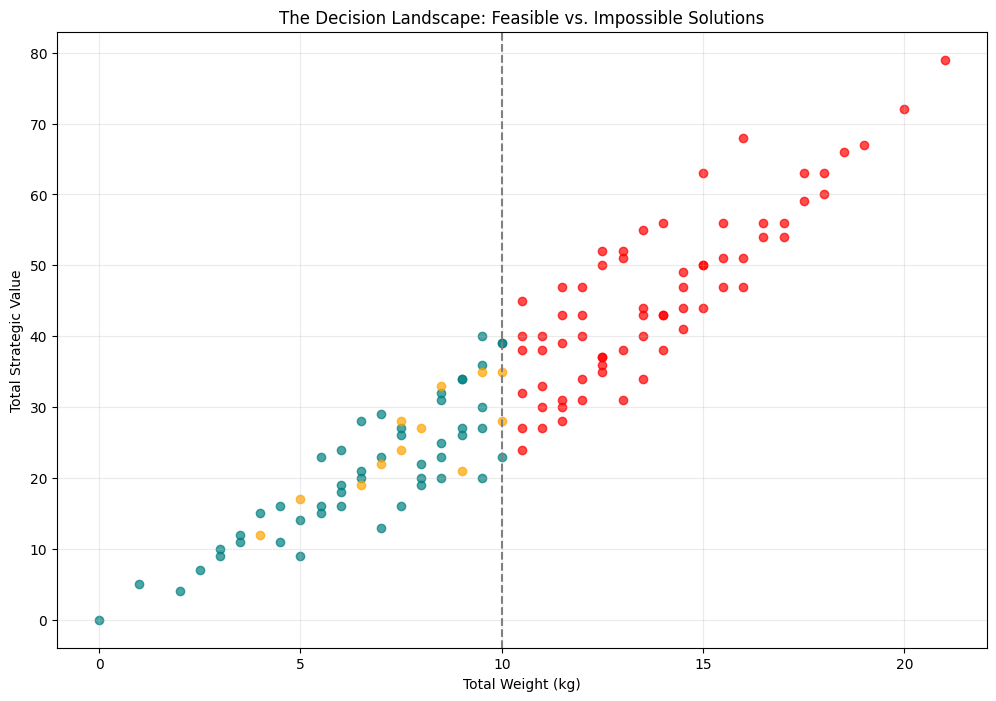

In [43]:
# 5. Visualizing the Decision Landscape (Scatter Plot)
plt.figure(figsize=(12, 8))
colors = {'Feasible': 'teal', 'Overweight': 'red', 'Logic Error': 'orange'}

for status, color in colors.items():
    subset = df_all[df_all['status'] == status]
    plt.scatter(subset['weight'], subset['value'], c = color, label = status, alpha = 0.7)

plt.axvline(x=max_capacity, color='gray', linestyle='--', label='Weight Limit')
plt.title("The Decision Landscape: Feasible vs. Impossible Solutions")
plt.xlabel("Total Weight (kg)")
plt.ylabel("Total Strategic Value")
## plt.legend()
plt.grid(True, alpha=0.25)
plt.show()